In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('AIML Dataset.csv')
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
df.shape

(6362620, 11)

In [5]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB


In [7]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


# EDA

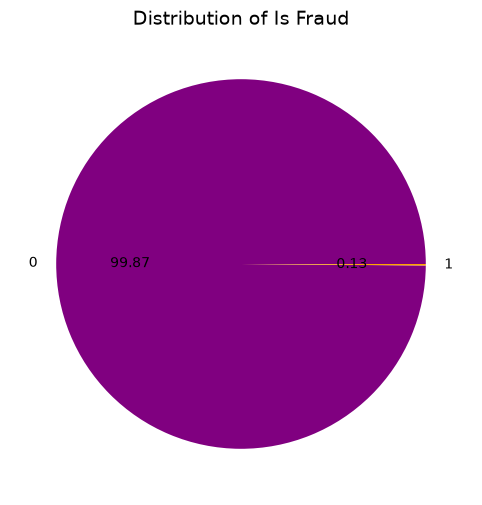

In [8]:
df['isFraud'].value_counts().plot(kind='pie', autopct='%.2f', figsize=(12,6), colors=['purple', 'orange'])
plt.title('Distribution of Is Fraud', fontsize=14)
plt.show()

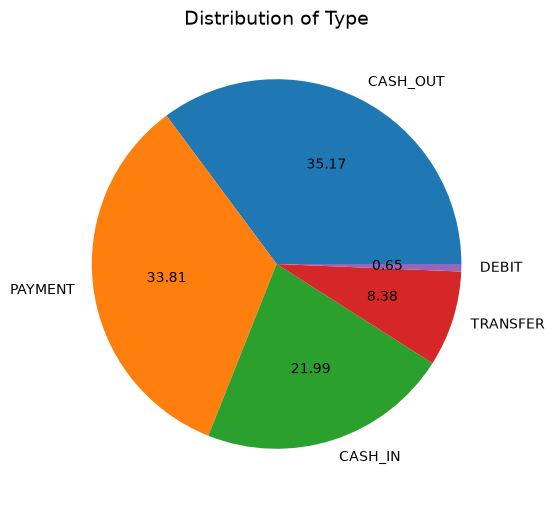

In [9]:
df['type'].value_counts().plot(kind='pie', autopct='%.2f', figsize=(12,6))
plt.title('Distribution of Type', fontsize=14)
plt.show()

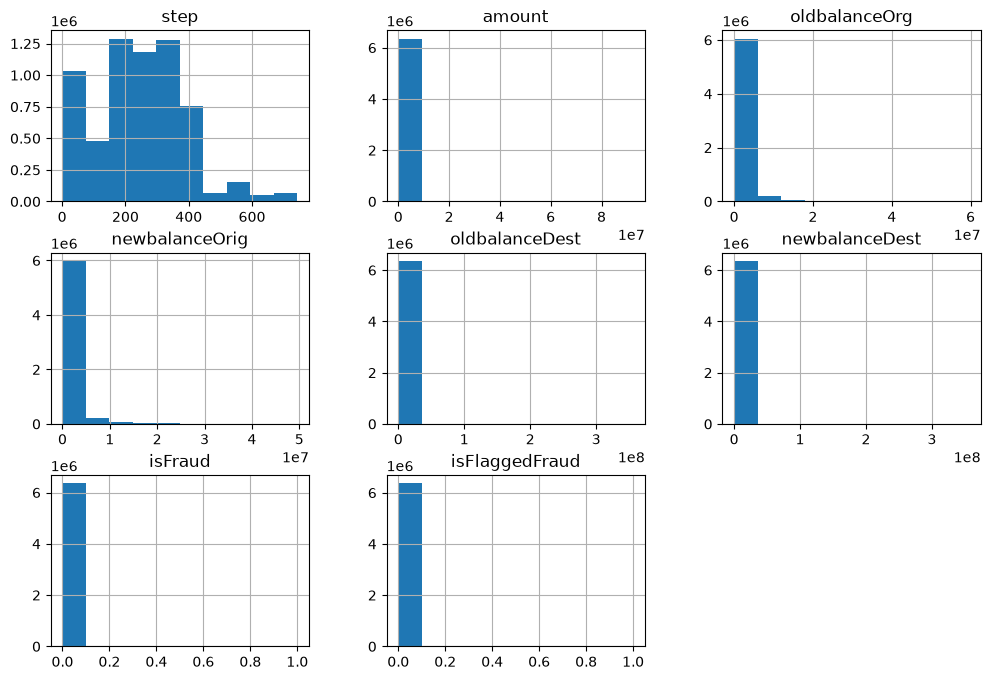

In [10]:
df.hist(figsize=(12,8))
plt.show()

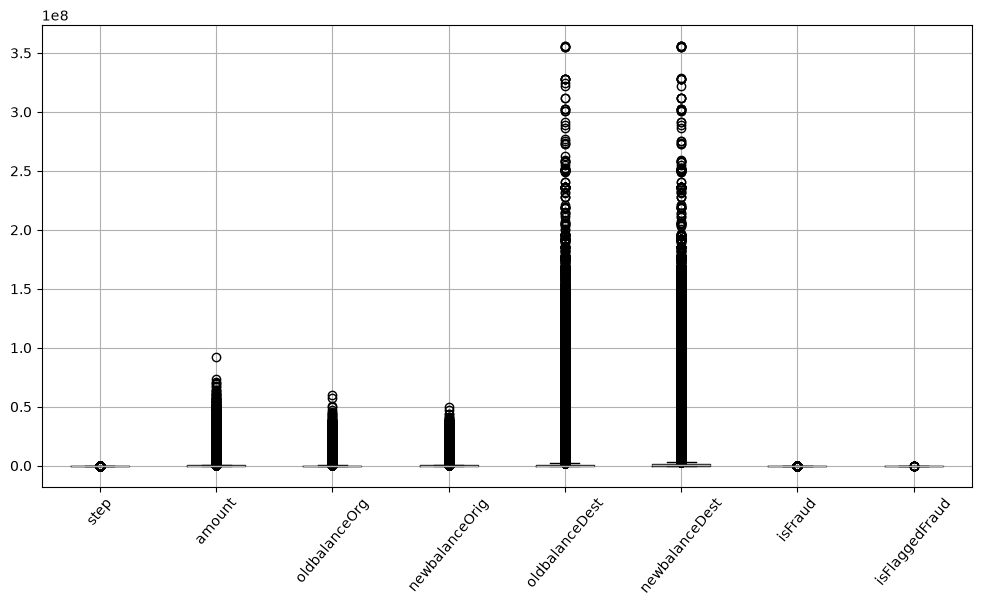

In [11]:
df.boxplot(figsize=(12,6))
plt.xticks(rotation=50)
plt.show()

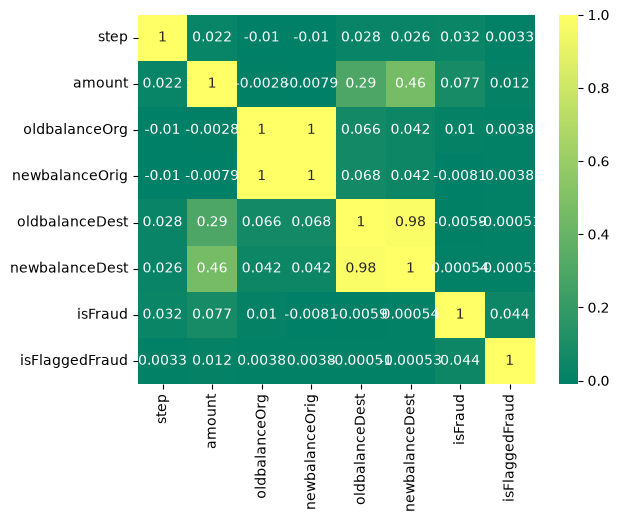

In [12]:
figsize=(9,6)
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='summer')
plt.show()

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score,confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder


In [15]:
df.drop(['nameOrig', 'nameDest'], axis=1, inplace=True)

# Label Encoding

In [16]:
le = LabelEncoder()
df['type']  = le.fit_transform(df['type'])


In [17]:
X = df.drop('isFraud', axis=1)
y = df['isFraud']
X_train,X_test, y_train,y_test = train_test_split(X,y , test_size=0.3)

In [18]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(4453834, 8)
(4453834,)
(1908786, 8)
(1908786,)


# Models Building

In [19]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier()
}


 Name: Logistic Regression
 Accuracy: 1.00
 Precision Score: 0.48863109048723896


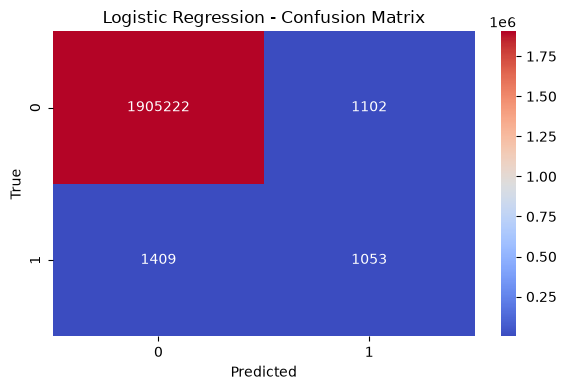


 Name: Random Forest
 Accuracy: 1.00
 Precision Score: 0.9799398194583752


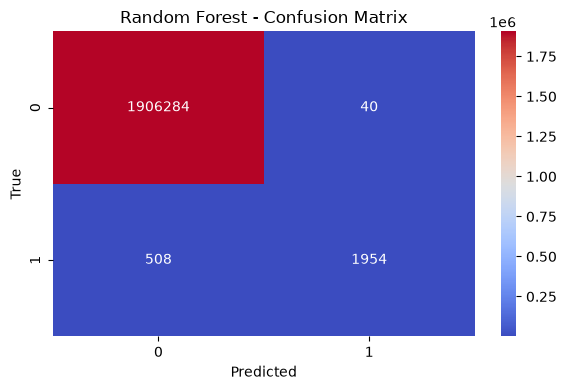


 Summary:


,Model,Accuracy,Precision
0,Logistic Regression,0.998685,0.488631
1,Random Forest,0.999713,0.979940


In [20]:
results = []
for model_names, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)

    print(f"\n Name: {model_names}")
    print(f" Accuracy: {acc:.2f}")
    print(f" Precision Score: {prec}")

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm')
    plt.title(f' {model_names} - Confusion Matrix ')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()



    results.append({
        'Model': model_names,
        'Accuracy': acc,
        'Precision': prec,
    })
    results_df = pd.DataFrame(results)

print("\n Summary:")
results_df

In [21]:
import joblib
trained_models={}
for model_name, model in models.items():
    model.fit(X_train,y_train)
    trained_models[model_name]=model

rf_model=trained_models["Random Forest"]
joblib.dump(rf_model,"fraud_detection_model.pkl")
joblib.dump(le,"label_encoder.pkl")
print("Saved model and encoder")


Saved model and encoder


In [23]:
model = joblib.load("fraud_detection_model.pkl")

print(model.feature_names_in_)


['step' 'type' 'amount' 'oldbalanceOrg' 'newbalanceOrig' 'oldbalanceDest'
 'newbalanceDest' 'isFlaggedFraud']


In [24]:
# Load model and encoder
model = joblib.load("fraud_detection_model.pkl")
le = joblib.load("label_encoder.pkl")

# Sample transaction
tx = {
    "step": 10,
    "type": "PAYMENT",
    "amount": 2500,
    "oldbalanceOrg": 5000,
    "newbalanceOrig": 2500,
    "oldbalanceDest": 10000,
    "newbalanceDest": 12500,
    "isFlaggedFraud": 0
}

# Encode transaction type
tx["type"] = le.transform([tx["type"]])[0]

# Convert to DataFrame
sample = pd.DataFrame([tx])

# Keep columns in the same order as training
sample = sample[model.feature_names_in_]

# Predict
pred = model.predict(sample)[0]
proba = model.predict_proba(sample)[0]

print("Prediction:", "Fraud" if pred == 1 else "Not Fraud")
print(f"Fraud Probability: {proba[1] * 100:.2f}%")
print(f"Not Fraud Probability: {proba[0] * 100:.2f}%")

Prediction: Not Fraud
Fraud Probability: 0.00%
Not Fraud Probability: 100.00%
